In [3]:
#import library
import rioxarray
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
#open dataset
raster_path = r"D:\Project\Forest Biomass\gedi_embedding_hutan_sulsel_0_5.tif"
open_raster = rioxarray.open_rasterio(raster_path)
open_raster

<xarray.DataArray (band: 65, y: 418, x: 288)> Size: 31MB
[7824960 values with dtype=float32]
Coordinates:
  * band         (band) int64 520B 1 2 3 4 5 6 7 8 9 ... 58 59 60 61 62 63 64 65
  * x            (x) float64 2kB 7.455e+05 7.465e+05 ... 1.032e+06 1.032e+06
  * y            (y) float64 3kB 9.784e+06 9.784e+06 ... 9.368e+06 9.368e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

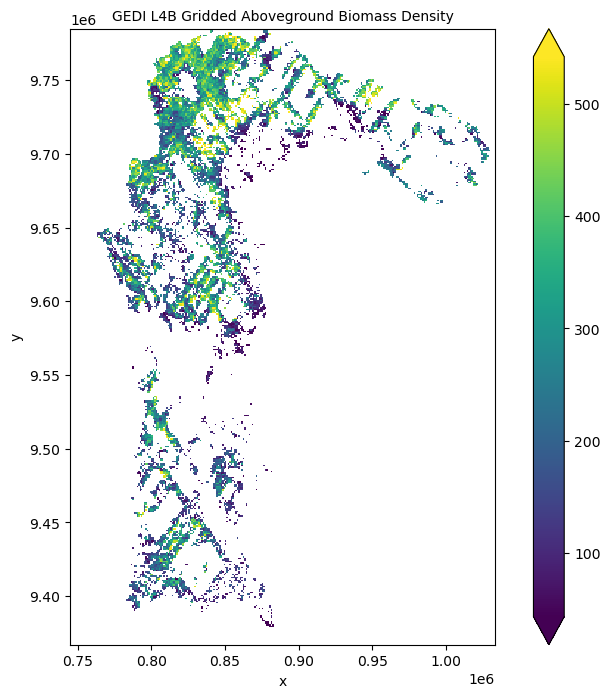

In [31]:
import matplotlib.pyplot as plt
band_visual = open_raster.isel(band=64) 

plt.figure(figsize=(10, 8))
band_visual.plot(cmap='viridis', robust=True)
plt.gca().set_aspect('equal')
plt.title('GEDI L4B Gridded Aboveground Biomass Density', fontsize =10)
plt.show()

In [5]:
#to dataset
dataset = open_raster.to_dataset(dim = 'band')
dataset

<xarray.Dataset> Size: 31MB
Dimensions:      (y: 418, x: 288)
Coordinates:
  * x            (x) float64 2kB 7.455e+05 7.465e+05 ... 1.032e+06 1.032e+06
  * y            (y) float64 3kB 9.784e+06 9.784e+06 ... 9.368e+06 9.368e+06
    spatial_ref  int64 8B 0
Data variables: (12/65)
    1            (y, x) float32 482kB ...
    2            (y, x) float32 482kB ...
    3            (y, x) float32 482kB ...
    4            (y, x) float32 482kB ...
    5            (y, x) float32 482kB ...
    6            (y, x) float32 482kB ...
    ...           ...
    60           (y, x) float32 482kB ...
    61           (y, x) float32 482kB ...
    62           (y, x) float32 482kB ...
    63           (y, x) float32 482kB ...
    64           (y, x) float32 482kB ...
    65           (y, x) float32 482kB ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [6]:
#convert the data to a dataframe
df_dataset = (
    dataset
    .to_dataframe()
    .reset_index()
    .drop(columns=['spatial_ref'])
    .set_index(['y', 'x'])
    .dropna(how='all')
)

In [7]:
#change name band 
band_list = ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 
             'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 
             'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'gedi']
df_dataset.columns = band_list

#### Prepare training and testing dataset

In [8]:
df_model = df_dataset.dropna()
df_model

A00       A01       A02       A03       A04  \
y         x                                                            
9783500.0 840500.0  0.103406  0.071111 -0.055363 -0.093564  0.206936   
          841500.0  0.088827  0.084214 -0.048228 -0.079723  0.172795   
          876500.0  0.166336  0.048228 -0.048228 -0.098424  0.221453   
          877500.0  0.160000  0.029773 -0.015748 -0.098424  0.236463   
          878500.0  0.172795  0.051734 -0.000984 -0.103406  0.236463   
...                      ...       ...       ...       ...       ...   
9380500.0 880500.0  0.071111  0.062991 -0.160000 -0.214133 -0.098424   
          882500.0  0.044844  0.051734 -0.186082 -0.221453 -0.071111   
9379500.0 880500.0  0.066990  0.066990 -0.147697 -0.221453 -0.088827   
          881500.0  0.062991  0.032541 -0.186082 -0.244152 -0.044844   
          882500.0  0.035433  0.027128 -0.179377 -0.244152 -0.059116   

                         A05       A06       A07       A08       A09  ...  \
y         x                                                           ...   
9783500.0 840500.0 -0.160000 -0.166336  0.013841  0.228897  0.038447  ...   
          841500.0 -0.135886 -0.147697  0.017778  0.236463  0.024606  ...   
          876500.0 -0.141730 -0.153787 -0.044844  0.192910  0.113741  ...   
          877500.0 -0.172795 -0.172795 -0.017778  0.199862  0.088827  ...   
          878500.0 -0.166336 -0.153787 -0.015748  0.206936  0.098424  ...   
...                      ...       ...       ...       ...       ...  ...   
9380500.0 880500.0  0.051734  0.119093  0.244152 -0.098424  0.084214  ...   
          882500.0  0.055363  0.130165  0.221453 -0.062991  0.038447  ...   
9379500.0 880500.0  0.079723  0.113741  0.236463 -0.079723  0.093564  ...   
          881500.0  0.059116  0.124567  0.228897 -0.103406  0.051734  ...   
          882500.0  0.066990  0.130165  0.228897 -0.079723  0.038447  ...   

                         A55       A56       A57       A58       A59  \
y         x                                                            
9783500.0 840500.0 -0.130165  0.075356 -0.079723 -0.079723  0.071111   
          841500.0 -0.135886  0.130165 -0.084214 -0.066990  0.048228   
          876500.0 -0.166336  0.075356 -0.075356 -0.103406  0.029773   
          877500.0 -0.153787  0.071111 -0.098424 -0.098424  0.066990   
          878500.0 -0.172795  0.084214 -0.103406 -0.098424  0.062991   
...                      ...       ...       ...       ...       ...   
9380500.0 880500.0 -0.103406  0.103406 -0.130165 -0.147697  0.160000   
          882500.0 -0.103406  0.108512 -0.130165 -0.119093  0.130165   
9379500.0 880500.0 -0.093564  0.108512 -0.119093 -0.166336  0.179377   
          881500.0 -0.124567  0.088827 -0.130165 -0.135886  0.147697   
          882500.0 -0.098424  0.088827 -0.135886 -0.130165  0.153787   

                         A60       A61       A62       A63        gedi  
y         x                                                             
9783500.0 840500.0  0.084214  0.088827  0.041584 -0.292872  372.693207  
          841500.0  0.141730  0.059116  0.051734 -0.199862  222.466873  
          876500.0  0.093564  0.093564  0.093564 -0.267958  210.611389  
          877500.0  0.124567  0.093564  0.098424 -0.251965  235.571548  
          878500.0  0.098424  0.093564  0.093564 -0.236463  236.553345  
...                      ...       ...       ...       ...         ...  
9380500.0 880500.0  0.051734 -0.119093 -0.098424 -0.130165   18.331980  
          882500.0  0.015748 -0.119093 -0.079723 -0.147697   25.653595  
9379500.0 880500.0  0.066990 -0.135886 -0.098424 -0.130165   15.210571  
          881500.0  0.029773 -0.141730 -0.075356 -0.172795   18.049374  
          882500.0  0.041584 -0.147697 -0.048228 -0.172795   46.791672  

[13230 rows x 65 columns]

In [9]:
#split dataset
X = df_model.drop('gedi', axis=1)
y = df_model['gedi']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size= 0.2,
    random_state= 42
)

#### XGBoost

In [10]:
# Grid Parameter
xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [400, 500, 600, 700],
    'subsample': [0.8, 1.0]
}

# Setup GridSearchCV
xgb_gs = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=xgb_param_grid,
    scoring='neg_mean_squared_error', # Gunakan MSE untuk regresi
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [11]:
#Fitting Model
xgb_gs.fit(X_train, y_train)

#Output
print("Best XGBoost Params:", xgb_gs.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best XGBoost Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}


In [12]:
#Evaluation
y_pred_xgb = xgb_gs.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Val RMSE: {mse:.3f}")
print(f"XGBoost Val R2 Score: {r2:.3f}")

XGBoost Val RMSE: 80.396
XGBoost Val R2 Score: 0.639


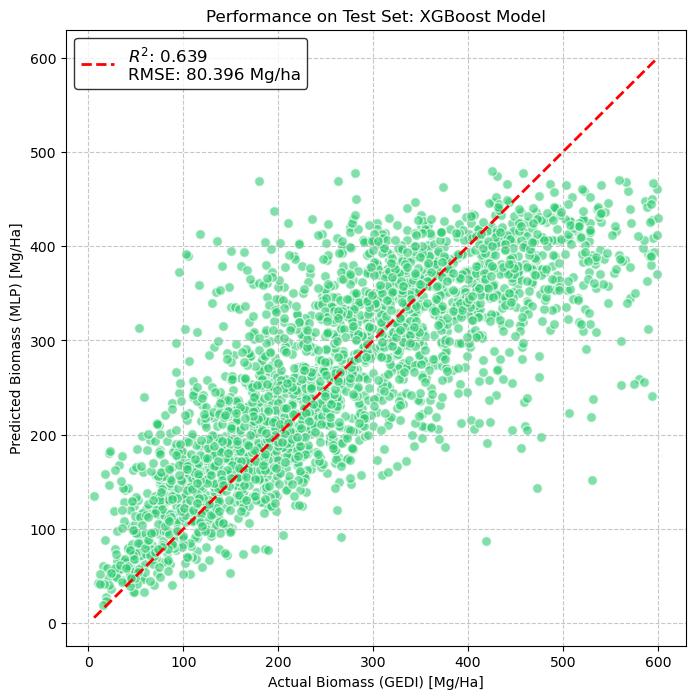

In [13]:
#visualization
import matplotlib.pyplot as plt

# RMSE and R2
rmse_val = 80.396
r2_val = 0.639

# Create text for the legend (using LaTeX for R squared)
# \n is used to create a new line to keep the legend box tidy
stats_label = f"$R^2$: {r2_val:.3f}\nRMSE: {rmse_val:.3f} Mg/ha"

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='#2ecc71', edgecolor='white', s=50)

# Diagonal line 1:1
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label=stats_label)
plt.legend(loc='upper left', fontsize=12, frameon=True, edgecolor='black')
plt.xlabel('Actual Biomass (GEDI) [Mg/Ha]')
plt.ylabel('Predicted Biomass (MLP) [Mg/Ha]')
plt.title('Performance on Test Set: XGBoost Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Inference Model

In [14]:
#preaper dataset for infrance
df_dataset= df_dataset.drop('gedi', axis = 1)
df_dataset['predic_agbm'] = xgb_gs.predict(df_dataset)


In [20]:
# min predic biomass
min_val = df_dataset['predic_agbm'].min()

# max predic biomasss
max_val = df_dataset['predic_agbm'].max()

print(f"Min Biomass: {min_val:.2f}")
print(f"Mas Biomass {max_val:.2f}")

Min Biomass: 15.72
Mas Biomass 522.41


<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10208\3355130530.py:7: SyntaxWarning: invalid escape sequence '\P'
  path_shp = 'D:\Project\Forest Biomass\shp\sulsel\sulsel.shp'


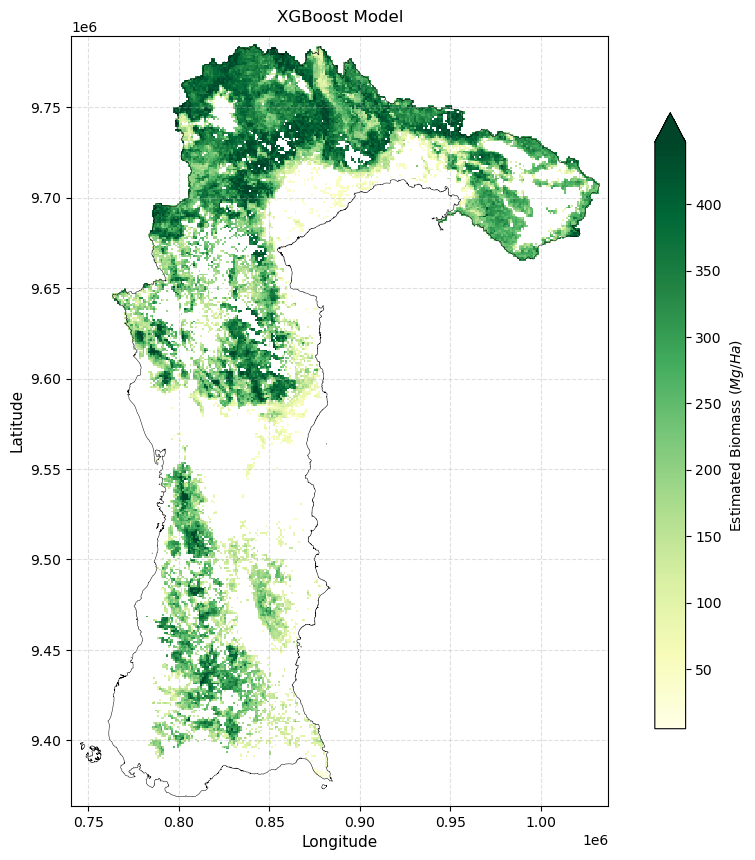

In [22]:
import geopandas as gpd

#visualizatiom
data_inference = df_dataset.to_xarray().sortby('x').sortby('y')

#load shapefile
path_shp = 'D:\Project\Forest Biomass\shp\sulsel\sulsel.shp' 
gdf_sulsel = gpd.read_file(path_shp)
gdf_sulsel = gdf_sulsel.to_crs(epsg=32750)

plt.figure(figsize=(12, 10))
ax = plt.gca() # Mengambil axes yang aktif

# Plotting data from xarray
# robust=True is very helpful so that color contrast is not damaged by GEDI outliers
plot = data_inference['predic_agbm'].plot(
    ax=ax,
    cmap='YlGn', 
    robust=True,
    vmin = 5,
    cbar_kwargs={'label': 'Estimated Biomass ($Mg/Ha$)', 'shrink': 0.8}
)

#plot shp
gdf_sulsel.plot(
    ax=ax, 
    color='none', 
    edgecolor='black', 
    linewidth=0.35, 
    label='Batas Administrasi'
)

# Get the coordinate limits from SHP (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = gdf_sulsel.total_bounds

# Provides a little "padding"
padding = 5000 
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

# 'equal' ensures that 1 degree Lat = 1 degree Lon in the visual display
# adjustable='box' ensures that the box plot remains neat even when the aspect is locked
ax.set_aspect('equal', adjustable='box')

plt.title('XGBoost Model', fontsize=12, pad=10)
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

#### Save to Geotif

In [23]:
ds_save = data_inference['predic_agbm']
save_data = ds_save.rio.write_crs('EPSG:32750')
save_data.rio.to_raster('forest_biomass_predic_xgboost.tif')

In [ ]:
import rioxarray
import xarray as xr

lc = rioxarray.open_rasterio(r"D:\Project\Forest Biomass\raster\Hutan_LuwuUtara_2024.tif")
biomass = rioxarray.open_rasterio(r"D:\Project\Forest Biomass\raster\gedi_embedding_100m.tif")

forest_mask_matched = lc.rio.reproject_match(biomass)


# Misal: area hutan memiliki nilai 1 di raster mask
masked_bio = biomass .where(forest_mask_matched == 1)

masked_bio.rio.to_raster("gedi_embedding_hutan_saja.tif")

In [2]:
import rioxarray
import xarray as xr
import numpy as np

# 1. Load data
lc = rioxarray.open_rasterio(r"D:\Project\Forest Biomass\raster\Hutan_Sulsel2019_0_6.tif")
biomass = rioxarray.open_rasterio(r"D:\Project\Forest Biomass\raster\GEDI_Biomass_Sulsel_1km_new.tif")

# 2. Penyelarasan
forest_mask_matched = lc.rio.reproject_match(biomass)

# 3. Buat Mask 2D (CARA AMAN)
# Gunakan .isel(band=0) untuk mengambil band pertama tanpa peduli apa namanya
# Kita tidak perlu .squeeze() lagi karena .isel sudah mereduksi dimensi tersebut
mask_hutan = (forest_mask_matched.isel(band=0) == 1)

# Cek apakah mask ada isinya (opsional tapi disarankan)
print(f"Pixel hutan ditemukan: {mask_hutan.sum().values}")

# 4. Masking
masked_bio = biomass.where(mask_hutan)

# 5. Pastikan urutan dimensi (band, y, x)
masked_bio = masked_bio.transpose('band', 'y', 'x')

# 6. Bersihkan metadata band
if 'long_name' in masked_bio.attrs:
    del masked_bio.attrs['long_name']

# 7. Simpan
masked_bio.rio.to_raster("gedi_embedding_hutan_sulsel_0_6.tif")

print("Selesai! Data sudah tersimpan.")

Pixel hutan ditemukan: 19093
Selesai! Data sudah tersimpan.
